# Opening the "Black Box"
## Act I — How does a neural network learn?

**Universidad Panamericana — May 21, 2026** · Eduardo Dueñez, UTSA

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eduenez/public-site/blob/main/2026-UPanamericana-mathAI/notebooks/act1_mnist_demo.ipynb)

---

Live demo for **Act I** of the talk. We will:

1. Load the **MNIST** handwritten-digit dataset.
2. Build a tiny **multi-layer perceptron** (two linear maps + one non-linearity).
3. **Train it** in about 30 seconds with stochastic gradient descent.
4. **Predict** on unseen digits — and discover what the network knows.

By the end we land the first **mathematical surprise** of the talk.


---
# 0. Setup

This notebook runs in **two environments**:

- **Google Colab** — click the badge above. Required packages auto-install below.
- **Local Jupyter** — install dependencies via `pip install -r requirements.txt` from the
  repo root, then open this file with `jupyter lab` or `jupyter notebook`.

The cell below detects the environment, installs missing packages if on Colab, and imports
what we need.


In [1]:
# @title Runtime setup (run me first)
import os, subprocess, sys

# ── Colab? Install missing packages. ─────────────────────────────────────
try:
    import google.colab  # noqa: F401
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "keras", "jax"],
        check=False,
    )
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

# ── Imports ──────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

np.random.seed(42)
keras.utils.set_random_seed(42)

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "figure.dpi": 100,
})

print(f"Keras {keras.__version__}  (backend: {keras.backend.backend()})")
print(f"Running on {'Colab' if _IN_COLAB else 'local Jupyter'}")


Keras 3.13.2  (backend: tensorflow)
Running on local Jupyter


---
# 1. The data: MNIST handwritten digits

MNIST is the *Drosophila* of computer vision: **70,000 grayscale images** of handwritten digits
0–9, each **28×28 pixels** (60,000 for training, 10,000 for testing).

Mathematically, each image is a point in $\mathbb{R}^{28\times 28} \cong \mathbb{R}^{784}$. The
classification task is to learn a function

$$
f \colon \mathbb{R}^{784} \longrightarrow \{0, 1, 2, \ldots, 9\}.
$$


Training set: 60,000 images of shape (28, 28)
Test set:     10,000 images


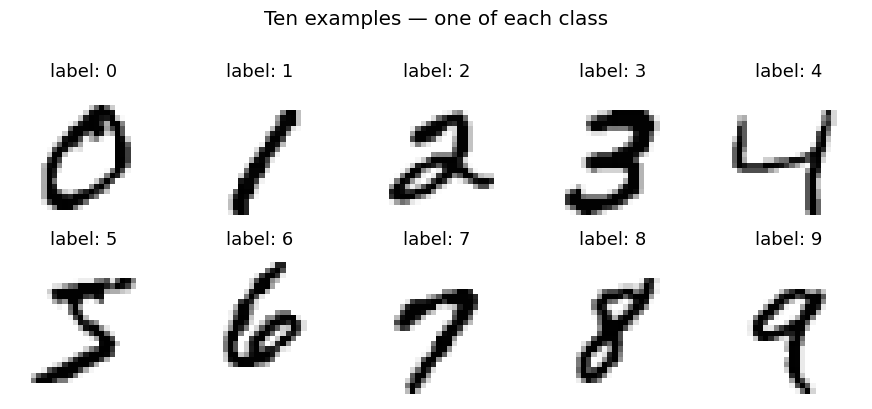

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]; flatten 28×28 → 784.
x_train = x_train.astype("float32") / 255.0
x_test  = x_test .astype("float32") / 255.0
x_train_flat = x_train.reshape(-1, 784)
x_test_flat  = x_test .reshape(-1, 784)

print(f"Training set: {x_train.shape[0]:,} images of shape {x_train.shape[1:]}")
print(f"Test set:     {x_test .shape[0]:,} images")

# ── Visualize one example of each digit class ────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for cls in range(10):
    idx = np.where(y_train == cls)[0][0]
    ax = axes[cls // 5, cls % 5]
    ax.imshow(x_train[idx], cmap="gray_r")
    ax.set_title(f"label: {cls}")
    ax.axis("off")
fig.suptitle("Ten examples — one of each class", y=1.02)
plt.tight_layout()
plt.show()


---
# 2. The model: a tiny multi-layer perceptron

The simplest non-trivial neural network: **two linear maps with a non-linearity between them**.

$$
\hat{\mathbf y}(\mathbf x)
  \;=\; W_2 \, \sigma\!\bigl(W_1 \mathbf x + \mathbf b_1\bigr) + \mathbf b_2.
$$

- $W_1 \in \mathbb{R}^{128 \times 784}$, $\mathbf b_1 \in \mathbb{R}^{128}$ — the **hidden layer**.
- $\sigma = \mathrm{ReLU}$, applied component-wise — the **non-linearity**.
- $W_2 \in \mathbb{R}^{10 \times 128}$, $\mathbf b_2 \in \mathbb{R}^{10}$ — the **output layer**
  (raw logits, one per class).

All trainable parameters live in the matrices $W_1, W_2$ and bias vectors $\mathbf b_1, \mathbf b_2$.


In [3]:
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu", name="hidden"),
    layers.Dense(10,                      name="output"),   # logits
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

---
# 3. Training: 30 seconds of gradient descent

We compile the model with:

- **Loss:** sparse categorical cross-entropy on the logits.
- **Optimizer:** Adam (a smart variant of SGD that adapts the learning rate per parameter).

Each training step is, conceptually,

$$
\mathbf w \;\longleftarrow\; \mathbf w \,-\, \eta \, \nabla_{\mathbf w} L(\mathbf w).
$$

The chain rule (a.k.a. **backpropagation**) computes the gradient automatically, layer by layer.


Epoch 1/8


422/422 - 1s - 3ms/step - accuracy: 0.8971 - loss: 0.3734 - val_accuracy: 0.9558 - val_loss: 0.1688


Epoch 2/8


422/422 - 1s - 2ms/step - accuracy: 0.9506 - loss: 0.1710 - val_accuracy: 0.9658 - val_loss: 0.1256


Epoch 3/8


...

Epoch 7/8


422/422 - 1s - 1ms/step - accuracy: 0.9856 - loss: 0.0519 - val_accuracy: 0.9752 - val_loss: 0.0839


Epoch 8/8


422/422 - 1s - 2ms/step - accuracy: 0.9885 - loss: 0.0433 - val_accuracy: 0.9752 - val_loss: 0.0835



Final test accuracy: 97.36%


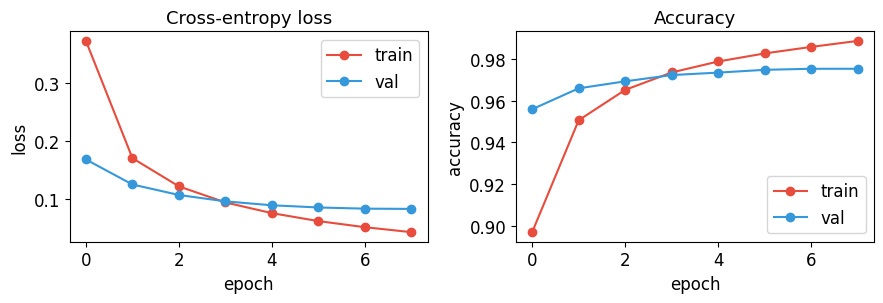

In [4]:
model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

history = model.fit(
    x_train_flat, y_train,
    epochs=8, batch_size=128,
    validation_split=0.1,
    verbose=2,
)

test_loss, test_acc = model.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nFinal test accuracy: {test_acc:.2%}")

# ── Learning curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].plot(history.history["loss"],     "-o", color="#e74c3c", label="train")
axes[0].plot(history.history["val_loss"], "-o", color="#3498db", label="val")
axes[0].set(xlabel="epoch", ylabel="loss", title="Cross-entropy loss")
axes[0].legend()
axes[1].plot(history.history["accuracy"],     "-o", color="#e74c3c", label="train")
axes[1].plot(history.history["val_accuracy"], "-o", color="#3498db", label="val")
axes[1].set(xlabel="epoch", ylabel="accuracy", title="Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()


---
# 4. Predictions: what does the network actually know?

Inference is a single forward pass, followed by a softmax to turn logits into probabilities:

$$
\hat{\mathbf p}(\mathbf x)
  \;=\; \mathrm{softmax}\!\Bigl(W_2 \,\sigma\!\bigl(W_1 \mathbf x + \mathbf b_1\bigr) + \mathbf b_2\Bigr).
$$

We show 10 random test images with the predicted class and its confidence. **Green** = correct,
**red** = wrong.


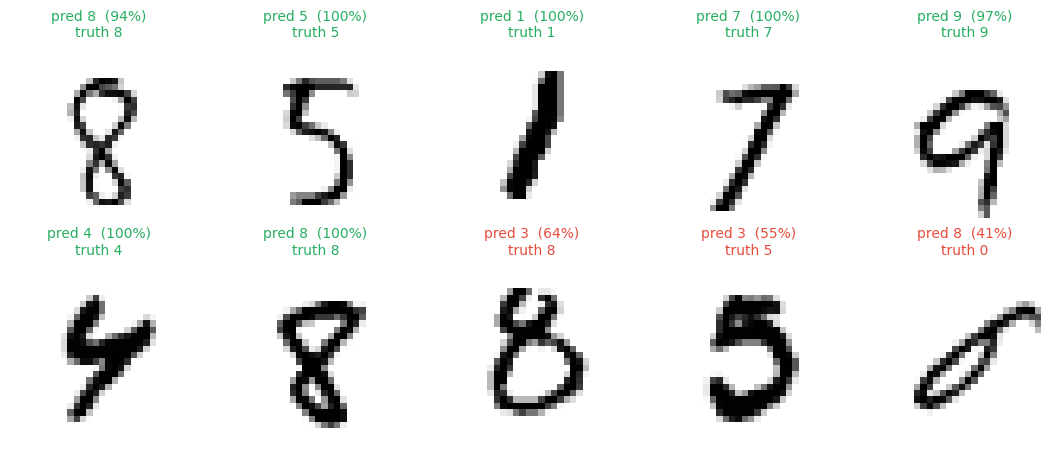

Errors in this batch: 3/10


In [5]:
# Sample a pool of test images, then show a mix of correct and wrong predictions.
rng = np.random.default_rng(0)
pool_idx = rng.choice(len(x_test), size=200, replace=False)

logits   = model.predict(x_test_flat[pool_idx], verbose=0)
exp_lg   = np.exp(logits - logits.max(axis=1, keepdims=True))
probs    = exp_lg / exp_lg.sum(axis=1, keepdims=True)
preds    = probs.argmax(axis=1)
confs    = probs.max(axis=1)
truths   = y_test[pool_idx]

wrong_mask = preds != truths
wrong_idx  = pool_idx[wrong_mask][:3]                  # up to 3 mistakes
correct_idx = pool_idx[~wrong_mask][:10 - len(wrong_idx)]
show_idx   = np.concatenate([wrong_idx, correct_idx])
rng.shuffle(show_idx)

# Recompute predictions for the chosen 10 (cheap; clearer code).
logits = model.predict(x_test_flat[show_idx], verbose=0)
exp_lg = np.exp(logits - logits.max(axis=1, keepdims=True))
probs  = exp_lg / exp_lg.sum(axis=1, keepdims=True)
preds  = probs.argmax(axis=1)
confs  = probs.max(axis=1)

fig, axes = plt.subplots(2, 5, figsize=(11, 4.6))
for k, ax in enumerate(axes.flat):
    truth = int(y_test[show_idx[k]])
    guess = int(preds[k])
    conf  = float(confs[k])
    color = "#27ae60" if guess == truth else "#e74c3c"
    ax.imshow(x_test[show_idx[k]], cmap="gray_r")
    ax.set_title(f"pred {guess}  ({conf:.0%})\ntruth {truth}",
                 color=color, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Errors in this batch: {(preds != y_test[show_idx]).sum()}/10")


---
# 🎉 Surprise #1 — Universal Approximation

Our network achieves $\approx 98\,\%$ accuracy on a 70 000-point dataset with **about 100 000
parameters**. *Why* is this possible at all?

> **Theorem (Cybenko 1989; Hornik 1991).**
> Let $K \subset \mathbb{R}^n$ be compact and let $\sigma$ be any non-constant, bounded,
> continuous function. Then finite-width feedforward networks of the form
> $$
> g(\mathbf x) \;=\; \sum_{i=1}^{N} c_i\, \sigma\!\bigl(\mathbf w_i^{\top}\mathbf x + b_i\bigr)
> $$
> are **dense in $C(K)$**: for every continuous $f \colon K \to \mathbb{R}$ and every
> $\varepsilon > 0$ there exists such a $g$ with
> $\sup_{\mathbf x \in K} |g(\mathbf x) - f(\mathbf x)| < \varepsilon$.

In other words: **one hidden layer with enough neurons can approximate any continuous function**,
to arbitrary accuracy.

This is a Stone-Weierstrass-flavored result. The deep mystery isn't whether neural networks
*can* represent the right function. They can. The mystery is:

> **Why can SGD on a non-convex loss surface, starting from random weights, find a good one in 30 seconds?**

That's the open question Act II picks up.
